In [1]:
import numpy as np
import matplotlib.pyplot as plt

from lammps import lammps, LMP_STYLE_GLOBAL,LMP_STYLE_ATOM, LMP_STYLE_LOCAL, LMP_TYPE_SCALAR
from lammps import LMP_TYPE_VECTOR, LMP_TYPE_ARRAY, LMP_SIZE_VECTOR, LMP_SIZE_ROWS, LMP_SIZE_COLS
from ctypes import c_double, c_int

In [2]:
#lmp = lammps()
lmp = lammps(cmdargs=['-screen', 'none'])

lmp.commands_string('''
#-------------------Various continuation commands----------------------
#atom_modify map yes

# ------------------------ INITIALIZATION ----------------------------
processors    * * *
units         metal
dimension    3
boundary    p    p    p
atom_style   atomic
atom_modify map yes


box        tilt large
#--------------------------- LAMMPS Data File--------------------------
read_data    basic_data/4b_step.lmp
change_box    all triclinic
reset_atom_ids sort yes

#--------------
pair_style    eam/alloy
pair_coeff    * * basic_data/Cu_mishin1.eam.alloy Cu

#-------------------Various continuation commands----------------------
compute forces all property/atom fx fy fz
compute ids all property/atom id
compute x_check all property/atom x y z
''')

#defaults:
natoms = lmp.extract_global("natoms")
original_box_size = lmp.extract_box()
ref_X = np.reshape(
            np.array(lmp.gather_atoms("x", 1, 3)),
            (natoms, 3),
        ).copy()

In [3]:
# saving energies, configurations, predicted next step configurations, IDs of atoms, values of sigma and max forces:
#energies
E = []
#optimal configurations
X = []

# IDs of atoms as assigned by LAMMPS
IDS = []

# values of continuation parameter
μs = []

#max force, unnused at the moment
max_force = []

#all forces
forces = []


for k in range(0,1650):
    lmp.command(f'read_dump dumps/tests/continuation_test_{k+1} 0 x y z box yes')
    lmp.command('run 0')
    _E = lmp.get_thermo("pe")
    _max_force = lmp.get_thermo("fmax")
    #_IDS = np.array(lmp.gather_atoms("id", 0, 1))
    _IDS = lmp.numpy.extract_compute('ids',LMP_STYLE_ATOM,LMP_TYPE_VECTOR).astype('int32')
    _F = lmp.numpy.extract_compute('forces',LMP_STYLE_ATOM,LMP_TYPE_ARRAY).copy()
    _X = np.reshape(
             np.array(lmp.gather_atoms("x", 1, 3)),
             (natoms, 3),
         )
    _μ = -(original_box_size[0][0] - lmp.extract_box()[0][0])
    E += [_E]
    X += [_X.copy()]
    IDS += [_IDS.copy()]
    max_force += [_max_force]
    forces += [_F]
    μs += [_μ]

In [6]:
displacements = np.array(X-ref_X) # dimensions (k,l,m) : (k+1)-th configuration, (l+1)-th atom, (m+1) direction 
displacements_norms = np.linalg.norm(displacements, axis=(1,2))

In [53]:
res[8]

237

In [10]:
res = [0]
for idx in range(1, len(μs) - 1):
    if np.sign(μs[idx + 1]-μs[idx])*np.sign(μs[idx]-μs[idx-1]) < 0:
        res += [idx]

np.sign(μs[65]-μs[64])

#μs[64]-μs[63]

res;

In [60]:
print([res[j], μs[res[j]]])
print([res[j+1], μs[res[j+1]]])

[282, 1.1260062812064504]
[327, 1.0526440322064445]


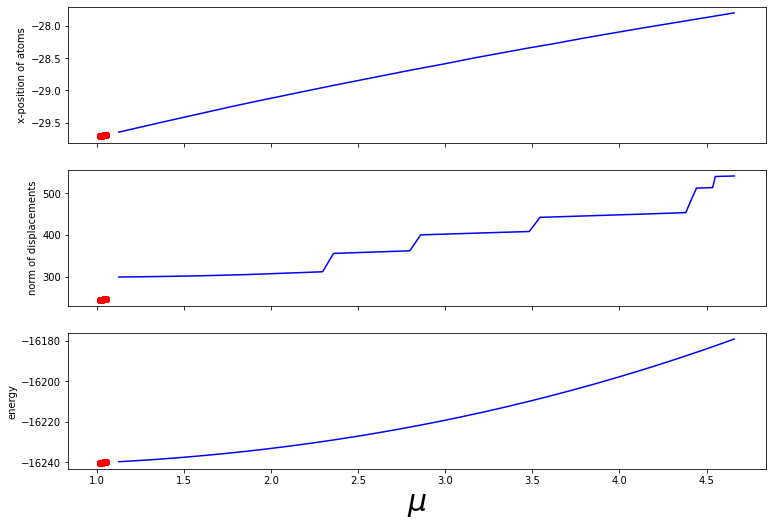

In [62]:
i = 7
j = 15
fig, (ax1,ax2,ax3) = plt.subplots(3,1,sharex=True)
fig.set_size_inches(12.5, 8.5, forward=True)

#ax1.plot(μs[:],np.array(X)[:,50,0],'b-')
ax1.plot(μs[res[i]:res[i+1]],np.array(X)[res[i]:res[i+1],51,0],'b-')
ax1.plot(μs[res[j]:res[j+1]],np.array(X)[res[j]:res[j+1],51,0],'ro-')
#ax1.plot(μs_c2[:],np.array(X_c2)[:,51,0],'r-')
#ax1.plot(μs[ii],np.array(X)[ii,50,0],'o',markersize=10)
#ax1.plot(μs[ii],np.array(X)[ii,51,0],'o',markersize=10)
ax1.set_ylabel("x-position of atoms")

ax2.plot(μs[res[i]:res[i+1]],displacements_norms[res[i]:res[i+1]],'b-')
ax2.plot(μs[res[j]:res[j+1]],displacements_norms[res[j]:res[j+1]],'ro-')
#ax2.plot(μs_c2[:],displacements_norms_c2,'r-')

#ax2.plot(μs_c[ii],displacements_norms_c[ii],'bo',markersize=10)
ax2.set_ylabel("norm of displacements")

ax3.plot(μs[res[i]:res[i+1]],E[res[i]:res[i+1]],'b-')
ax3.plot(μs[res[j]:res[j+1]],E[res[j]:res[j+1]],'ro-')
#ax3.plot(μs_c2[:],E_c2,'r-')
#ax3.plot(μs_c[ii],E_c[ii],'bo',markersize=10)
ax3.set_ylabel("energy")
ax3.set_xlabel(r"$\mu$")
ax3.xaxis.label.set_fontsize(30)